In [10]:
import pandas as pd
command_data = pd.read_csv('command_data.csv')
command_data = command_data[command_data['command_group'] == 'k8s_cluster_info_commands']

In [11]:
command_data

,id,command_group,command,description
128,129,k8s_cluster_info_commands,kubectl cluster-info,Display cluster information
129,130,k8s_cluster_info_commands,kubectl get nodes,List all nodes in the cluster
130,131,k8s_cluster_info_commands,kubectl get namespaces,List all namespaces in the cluster
131,132,k8s_cluster_info_commands,kubectl config get-contexts,List available contexts
132,133,k8s_cluster_info_commands,kubectl config use-context context_name,Switch to the specified context


In [12]:
count_data = pd.read_csv('count.csv')
count_data

,id,command_id,command,is_correct
0,4,19,docker service scale nginx_cluster=5,True
1,5,18,docker service ps nginx_cluster,True
2,6,16,docker service create --name nginx_cluster --r...,True
3,7,15,docker swarm init,True
4,8,21,docker service rm nginx_cluster,True
...,...,...,...,...
115,140,133,kubectl config use-context context_name,True
116,141,131,kubectl get namespaces,False
117,142,132,kubectl config get-contexts,True
118,143,130,kubectl get nodes,False


In [17]:
merged_data = pd.merge(command_data, count_data, left_on='id', right_on='command_id', how='left')
merged_data


,id_x,command_group,command_x,description,id_y,command_id,command_y,is_correct
0,129,k8s_cluster_info_commands,kubectl cluster-info,Display cluster information,135,129,kubectl cluster-info,True
1,129,k8s_cluster_info_commands,kubectl cluster-info,Display cluster information,144,129,kubectl cluster-info,False
2,130,k8s_cluster_info_commands,kubectl get nodes,List all nodes in the cluster,138,130,kubectl get nodes,False
3,130,k8s_cluster_info_commands,kubectl get nodes,List all nodes in the cluster,143,130,kubectl get nodes,False
4,131,k8s_cluster_info_commands,kubectl get namespaces,List all namespaces in the cluster,137,131,kubectl get namespaces,False
5,131,k8s_cluster_info_commands,kubectl get namespaces,List all namespaces in the cluster,141,131,kubectl get namespaces,False
6,132,k8s_cluster_info_commands,kubectl config get-contexts,List available contexts,139,132,kubectl config get-contexts,False
7,132,k8s_cluster_info_commands,kubectl config get-contexts,List available contexts,142,132,kubectl config get-contexts,True
8,133,k8s_cluster_info_commands,kubectl config use-context context_name,Switch to the specified context,136,133,kubectl config use-context context_name,False
9,133,k8s_cluster_info_commands,kubectl config use-context context_name,Switch to the specified context,140,133,kubectl config use-context context_name,True


In [30]:
summary = (
    merged_data.groupby('id_x')
    .agg(
        count_id_x=('id_x', 'count'),
        command_x=('command_x', 'first'),
        # description=('description', 'first'),
        total_count=('command_y', 'count'),
        correct_count=('is_correct', lambda x: (x == True).sum())
    )
    .reset_index()
    .sort_values(by=['total_count', 'correct_count'], ascending=[True, True])  # Sort by total_count, then correct_count
)
print(summary.to_string(index=False))

# summary = merged_data.groupby(['id_x', 'command_x', 'description'])['command_id'].count().reset_index(name='count_num')
# print(summary.to_string(index=False))

 id_x  count_id_x                               command_x  total_count  correct_count
  130           2                       kubectl get nodes            2              0
  131           2                  kubectl get namespaces            2              0
  129           2                    kubectl cluster-info            2              1
  132           2             kubectl config get-contexts            2              1
  133           2 kubectl config use-context context_name            2              1


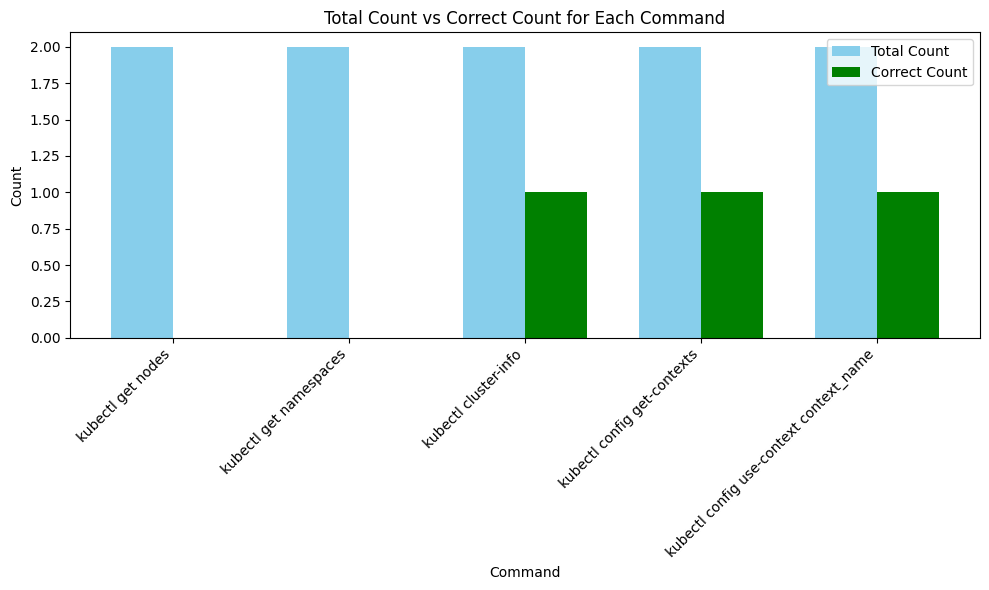

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 创建一个条形图，展示 total_count 和 correct_count，不让条形覆盖
import numpy as np

# 设置条形的宽度和位置
bar_width = 0.35
index = np.arange(len(summary['command_x']))

# 画出 total_count 和 correct_count，设置条形不重叠
ax.bar(index, summary['total_count'], width=bar_width, label='Total Count', color='skyblue', align='center')
ax.bar(index + bar_width, summary['correct_count'], width=bar_width, label='Correct Count', color='green', align='center')

# 更新 x 轴标签位置
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary['command_x'], rotation=45, ha='right')

# 设置标签和标题
ax.set_xlabel('Command')
ax.set_ylabel('Count')
ax.set_title('Total Count vs Correct Count for Each Command')
ax.set_xticklabels(summary['command_x'], rotation=45, ha='right')

# 显示图例
ax.legend()

# 调整布局并显示
plt.tight_layout()
plt.show()


/tmp/ipykernel_83810/4174389756.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(summary['command_x'], rotation=45, ha='right')
/tmp/ipykernel_83810/4174389756.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(summary['command_x'], rotation=45, ha='right')


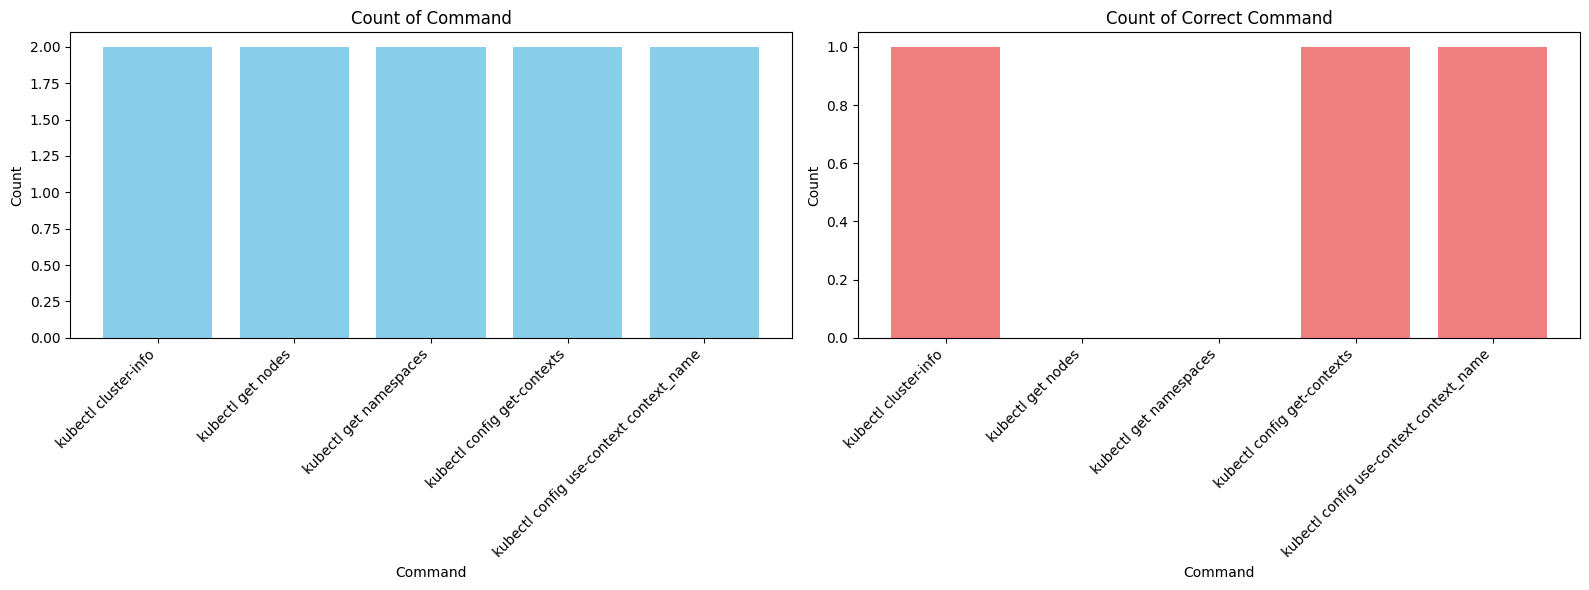

In [22]:
# import matplotlib.pyplot as plt

# 创建一个图形窗口，并设置大小
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左边显示 count_command_y
ax1.bar(summary['command_x'], summary['count_command_y'], label='Count of Command', color='skyblue')
ax1.set_xlabel('Command')
ax1.set_ylabel('Count')
ax1.set_title('Count of Command')
ax1.set_xticklabels(summary['command_x'], rotation=45, ha='right')

# 右边显示 count_is_correct_true
ax2.bar(summary['command_x'], summary['count_is_correct_true'], label='Count of Correct Command', color='lightcoral')
ax2.set_xlabel('Command')
ax2.set_ylabel('Count')
ax2.set_title('Count of Correct Command')
ax2.set_xticklabels(summary['command_x'], rotation=45, ha='right')

# 调整布局并显示图例
plt.tight_layout()
plt.show()


In [15]:
top_10_count = summary.nlargest(10, 'count_num')
print(top_10_count.to_string(index=False))

 id_x                               command_x                        description  count_num
  129                    kubectl cluster-info        Display cluster information          2
  130                       kubectl get nodes      List all nodes in the cluster          2
  131                  kubectl get namespaces List all namespaces in the cluster          2
  132             kubectl config get-contexts            List available contexts          2
  133 kubectl config use-context context_name    Switch to the specified context          2


In [16]:
min_10_count = summary.nsmallest(10, 'count_num')
print(min_10_count.to_string(index=False))


 id_x                               command_x                        description  count_num
  129                    kubectl cluster-info        Display cluster information          2
  130                       kubectl get nodes      List all nodes in the cluster          2
  131                  kubectl get namespaces List all namespaces in the cluster          2
  132             kubectl config get-contexts            List available contexts          2
  133 kubectl config use-context context_name    Switch to the specified context          2
